![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 4. Process Design Kit (PDK) and Layout

In [1]:
import gdsfactory as gf

## 1. Technology

We will work with the **demo UPVfab PDK**. (There are some other open-source PDKs, in other technologies, feel free to search if interested)

In [2]:
from upvfab.sin300.cband import PDK, cells

Let's view the layer distribution of this PDK. In our case, for the passive devices we will only use the **Layer 1**. 

2026-06-12 10:51:49.498 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


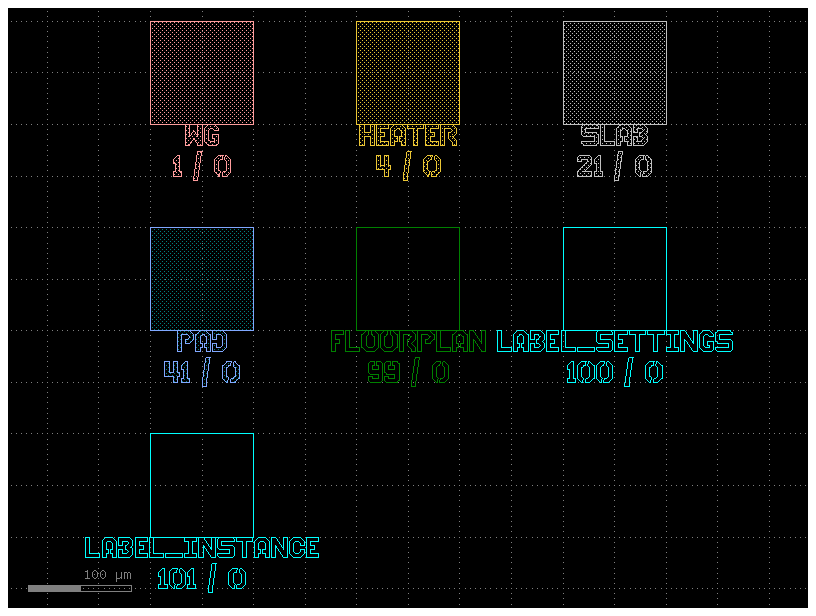

In [3]:
LAYER_VIEWS = PDK.layer_views
c = LAYER_VIEWS.preview_layerset()
c.show()
c.plot()


The new versions of GDS Factory allow to view the Layer Stack also (3D view of the fabrication flow). The following code allows to generate and view the Layer Stack of the generic PDK. Reference: https://www.degruyter.com/document/doi/10.1515/nanoph-2013-0034/html

The layers and the thicknesses have been defined previously on the PDK, so it is possible to view in 3D some of the components in the PDK. 

See the [Reference Manual](https://gdsfactory.github.io/gdsfactory/components.html) and read the list of the available components.

Here are some examples of the 3D views of this photonic components

2026-06-12 10:51:49.736 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


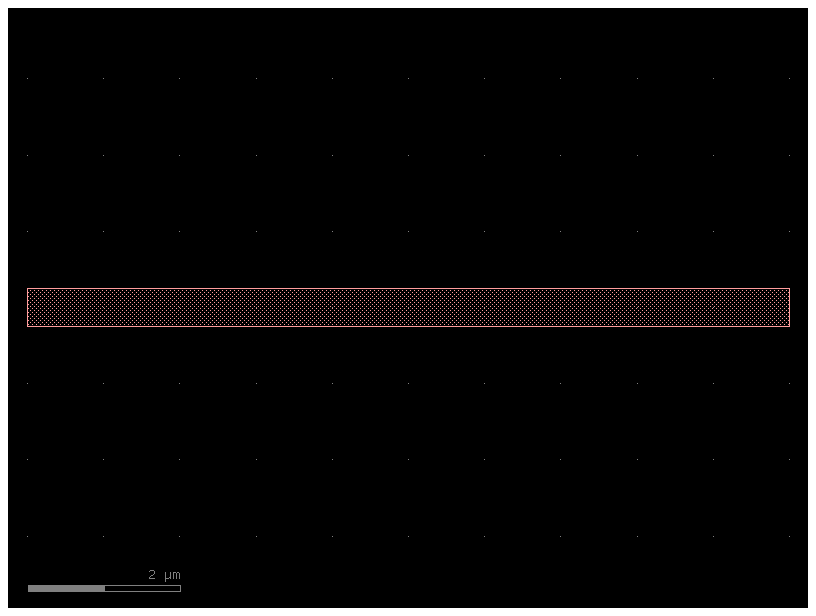

In [4]:
xs = gf.cross_section.strip(width=0.5, layer = 'WG')

c = gf.components.straight(length=10, cross_section=xs)  #Deep 
c.plot() # To view the component on Notebook
c.show() # To view on KLayout
scene = c.to_3d()
scene.show()


2026-06-12 10:51:49.926 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server
2026-06-12 10:51:49.960 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


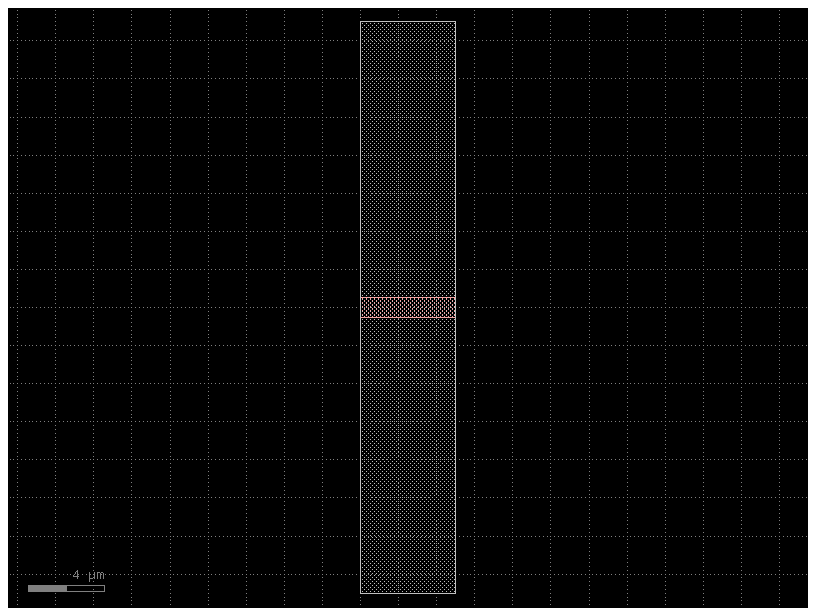

In [5]:
c = gf.components.straight(length=5, cross_section='rib') #Shallow
c.plot()
c.show()

scene = c.to_3d()
c.show()
scene.show()

In [6]:
c = cells.taper_strip_to_ridge(length=10) #Taper
c.show()

scene = c.to_3d()
scene.show()

2026-06-12 10:51:50.139 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


2026-06-12 10:51:50.276 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


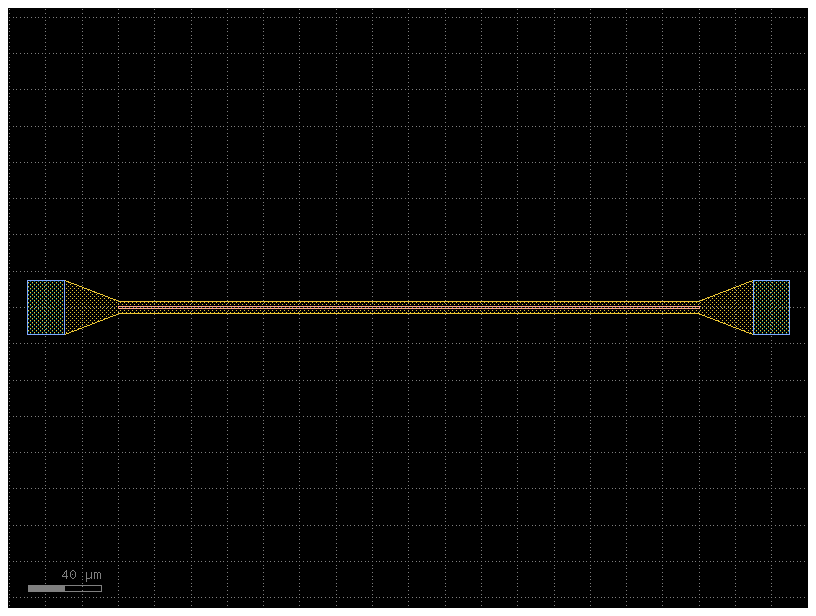

In [7]:
c = cells.straight_heater_metal()

#c.pprint_ports()

c.plot()
c.show()
#c.draw_ports()

scene = c.to_3d()
scene.show()

- Use your design results from Lab2 and Lab3 to create **layout** instances of your designed components: DCs, MMIs, MZIs & Ring Resonators. 

### A. Directional Couplers (DC)

2026-06-12 10:51:50.466 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


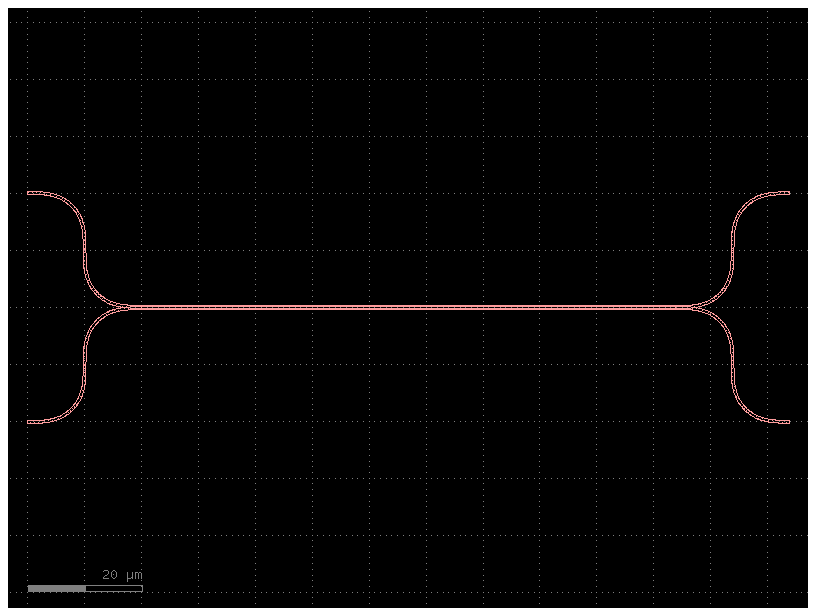

In [8]:
gf.clear_cache()
component_library = gf.Component()
length=93.84; gap=0.5; width=0.5; 

xs_strip = gf.cross_section.strip(width=0.5, layer="WG")
distancia_centros = width * gap  
    
# GUIAS DE ONDA
top_wvg = component_library.add_ref(gf.components.straight(length=length, cross_section=xs_strip)) 
top_wvg.dmovey(distancia_centros / 2)
    
bot_wvg = component_library.add_ref(gf.components.straight(length=length, cross_section=xs_strip)) 
bot_wvg.dmovey(-distancia_centros / 2)
    
# SALIDAS DEL ACOPLADOR
s_bend = gf.components.bend_euler_s(radius=10, cross_section=xs_strip)

s_in_top = component_library.add_ref(s_bend).dmirror_y().connect("o2", top_wvg.ports["o1"])
s_in_bot = component_library.add_ref(s_bend).connect("o2", bot_wvg.ports["o1"])

s_out_top = component_library.add_ref(s_bend).connect("o1", top_wvg.ports["o2"])
s_out_bot = component_library.add_ref(s_bend).dmirror_y().connect("o1", bot_wvg.ports["o2"])

component_library.plot()
component_library.show()

### B. Multi-Mode Interferometers (MMI)

2026-06-12 10:51:50.613 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


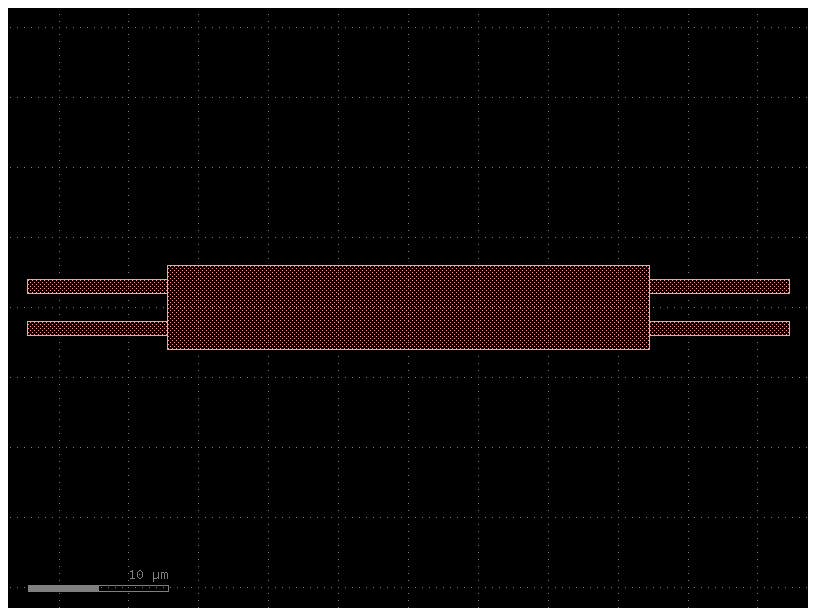

In [9]:
component_library = gf.Component()
length_mmi=34.518; length_dc=10; width_mmi=6.0; io_width=1.0; width=0.5; 

component_library = gf.Component()
    
cuerpo = component_library.add_ref(gf.components.rectangle(size=(length_mmi, width_mmi), layer='WG'))
cuerpo.dmovex(-length_mmi / 2).dmovey(-width_mmi / 2)
    
straight_in1 = component_library.add_ref(gf.components.straight(length=length_dc, cross_section='strip'))
straight_in2 = component_library.add_ref(gf.components.straight(length=length_dc, cross_section='strip'))
straight_out1 = component_library.add_ref(gf.components.straight(length=length_dc, cross_section='strip'))
straight_out2 = component_library.add_ref(gf.components.straight(length=length_dc, cross_section='strip'))
    
x_entrada = -(length_mmi / 2) - length_dc
straight_in1.dmovex(x_entrada).dmovey(width_mmi / 4)   # Entrada superior (o2)
straight_in2.dmovex(x_entrada).dmovey(-width_mmi / 4)  # Entrada inferior (o1)
 
x_salida = length_mmi / 2
straight_out1.dmovex(x_salida).dmovey(width_mmi / 4)   # Salida superior (o3)
straight_out2.dmovex(x_salida).dmovey(-width_mmi / 4)  # Salida inferior (o4)

component_library.plot()
component_library.show()

### C. Mach-Zehnder Interferometers (MZI)

2026-06-12 10:51:50.771 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


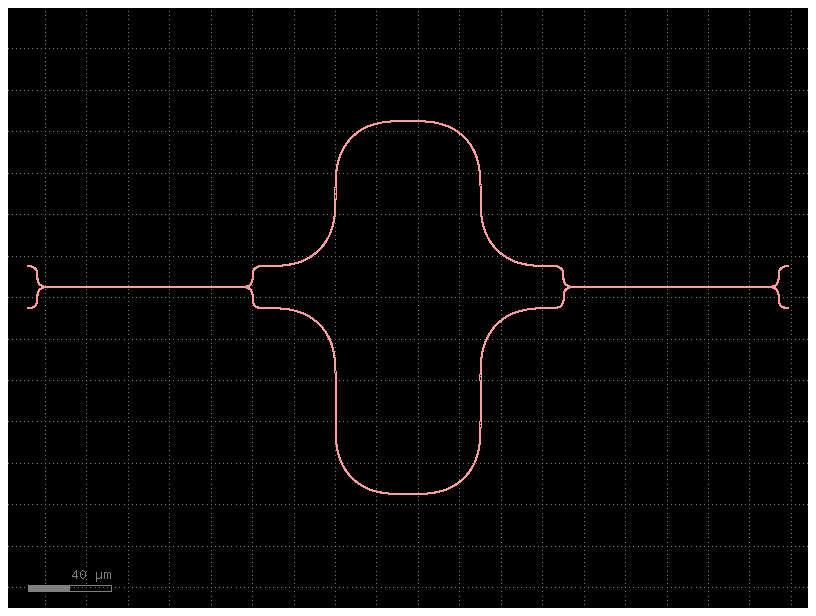

In [10]:
component_library = gf.Component()
delta_length=20.0; radius=35.0; gap=0.2; length_dc=12.25; width=0.5;
xs_strip = gf.cross_section.strip(width=0.5, layer="WG")

# ANILLO SUPERIOR
b1 = component_library.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip))
b2 = component_library.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip))
b3 = component_library.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip))
b4 = component_library.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip))

b1.drotate(270).dmovey(2*radius+20+gap).dmovex(2*radius) 
b2.connect("o1", b1.ports["o1"])
b3.connect("o1", b2.ports["o2"])
b4.connect("o2", b3.ports["o2"])

# ANILLO INFERIOR
b5 = component_library.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip))
b6 = component_library.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip))
b7 = component_library.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip))
b8 = component_library.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip))

# GUIAS LATERALES DEL ANILLO
v_straight_right = component_library.add_ref(gf.components.straight(length=delta_length, cross_section=xs_strip))
v_straight_left = component_library.add_ref(gf.components.straight(length=delta_length, cross_section=xs_strip))

b5.drotate(90).dmovey(0)
v_straight_left.drotate(90).connect("o2", b5.ports["o1"])
b6.connect("o1", v_straight_left.ports["o1"])
b7.connect("o1", b6.ports["o2"])
v_straight_right.drotate(90).connect("o1", b7.ports["o2"])
b8.connect("o2", v_straight_right.ports["o2"])

# =========================================================================
# ACOPLADOR DE LA DERECHA
# =========================================================================
top_wvg_right = component_library.add_ref(gf.components.straight(length=length, cross_section=xs_strip)).dmovey(0)
bot_wvg_right = component_library.add_ref(gf.components.straight(length=length, cross_section=xs_strip)).dmovey(0)
    
# SALIDAS DEL ACOPLADOR
s_bend_mzi = gf.components.bend_euler_s(radius=5, cross_section=xs_strip)

s_in_top_right = component_library.add_ref(s_bend_mzi)
s_out_top_right = component_library.add_ref(s_bend_mzi)
s_in_bot_right = component_library.add_ref(s_bend_mzi)
s_out_bot_right = component_library.add_ref(s_bend_mzi).dmirror_y()

s_out_top_right.connect("o1", b4.ports["o1"])
top_wvg_right.connect("o2", s_out_top_right["o2"])
s_in_top_right.dmirror_y().connect("o2", top_wvg_right.ports["o1"])
s_out_bot_right.connect("o1", b5.ports["o2"])
bot_wvg_right.connect("o2", s_out_bot_right["o2"])
s_in_bot_right.connect("o2", bot_wvg_right.ports["o1"])

# =========================================================================
# ACOPLADOR DE LA IZQUIERDA
# =========================================================================
top_wvg_left = component_library.add_ref(gf.components.straight(length=length, cross_section=xs_strip)).dmovey(0)
bot_wvg_left = component_library.add_ref(gf.components.straight(length=length, cross_section=xs_strip)).dmovey(0)
    
# SALIDAS DEL ACOPLADOR
s_bend_mzi = gf.components.bend_euler_s(radius=5, cross_section=xs_strip)

s_in_top_left = component_library.add_ref(s_bend_mzi)
s_out_top_left = component_library.add_ref(s_bend_mzi)
s_in_bot_left = component_library.add_ref(s_bend_mzi)
s_out_bot_left = component_library.add_ref(s_bend_mzi).dmirror_y()

s_in_top_left.dmirror_y().connect("o1", b1.ports["o2"])
top_wvg_left.connect("o1", s_in_top_left["o2"])
s_out_top_left.connect("o2", top_wvg_left.ports["o2"])
s_in_bot_left.connect("o2", b8.ports["o1"])
bot_wvg_left.connect("o1", s_in_bot_left["o1"])
s_out_bot_left.connect("o2", bot_wvg_left.ports["o2"])


component_library.plot()
component_library.show()

### D. Ring Resonators

2026-06-12 10:51:50.921 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


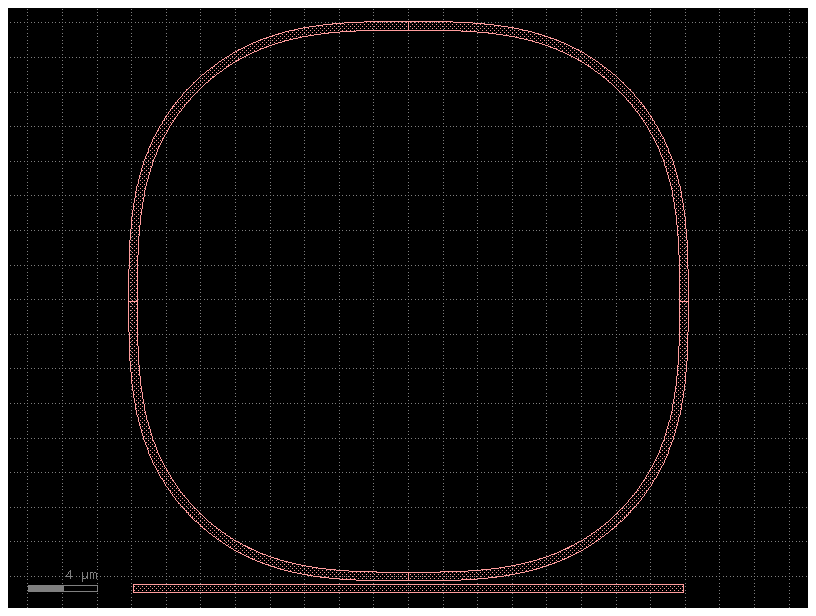

In [11]:
component_library = gf.Component()
radius=15.915; gap=0.2; width=0.5; length=0.0; 
xs_strip = gf.cross_section.strip(width=width, layer="WG")

b1 = component_library.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip))
b2 = component_library.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip)).connect("o1", b1.ports["o2"])
v_straight_right = component_library.add_ref(gf.components.straight(length=length, cross_section=xs_strip)).connect("o1", b2.ports["o2"])
b3 = component_library.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip)).connect("o1", v_straight_right.ports["o2"])
b4 = component_library.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip)).connect("o1", b3.ports["o2"])
v_straight_left = component_library.add_ref(gf.components.straight(length=length, cross_section=xs_strip)).connect("o1", b4.ports["o2"])


bus_length = 2 * radius + length
v_straight = component_library.add_ref(gf.components.straight(length=bus_length, cross_section=xs_strip))

y_bus = b1.ports["o1"].center[1] - (gap + width)
x_bus = b4.ports["o1"].center[0] 

v_straight.dmovex(x_bus).dmovey(y_bus)

component_library.plot()
component_library.show()

## 2. Layout Fundamentals

A cell is a function that returns a Component. In GDS each component must have a unique name. Two components stored in the GDS file cannot have the same name. They need to be references (instances) of the same component.

![GDSFactoryComponents][def]


[def]: https://i.imgur.com/oeuKGsc.png

2026-06-12 10:51:51.064 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


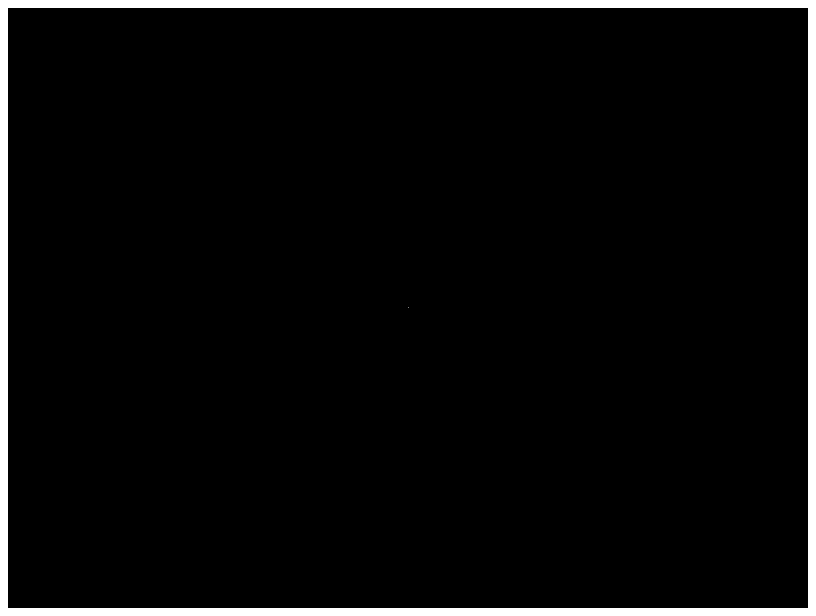

In [12]:
c = gf.Component()
c.plot()
c.show()

Let's build a Component from scratch. A die (chip) for a photonic layout. The PDK or Design Manual should specify the Layer for the bounding box (dicing line). 
We should also consider: 
1. The die dimensions and 
2. The border for dicing 

2026-06-12 10:51:51.189 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


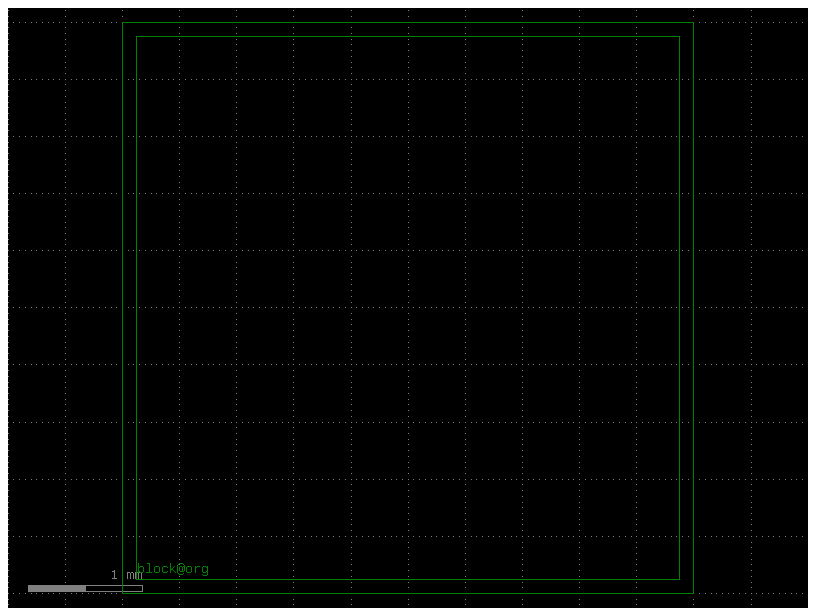

In [13]:
wgw = 0.5
dieL = 5000
dieW = 5000
border = 125
layer_wg = "WG"
layer_box = "FLOORPLAN"

# Die specifications (Chip)
box = gf.Component()

obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
box = gf.boolean(A=obox, B=ibox, operation="A-B", layer="FLOORPLAN")

# Adding ports to a component 
box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)

box.draw_ports()
box.show()
box.plot()

### Mantra: 
Once that we have a working 'new' component, we shall convert it into a Cell. This will allow us to have a hierarchical design

2026-06-12 10:51:51.376 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


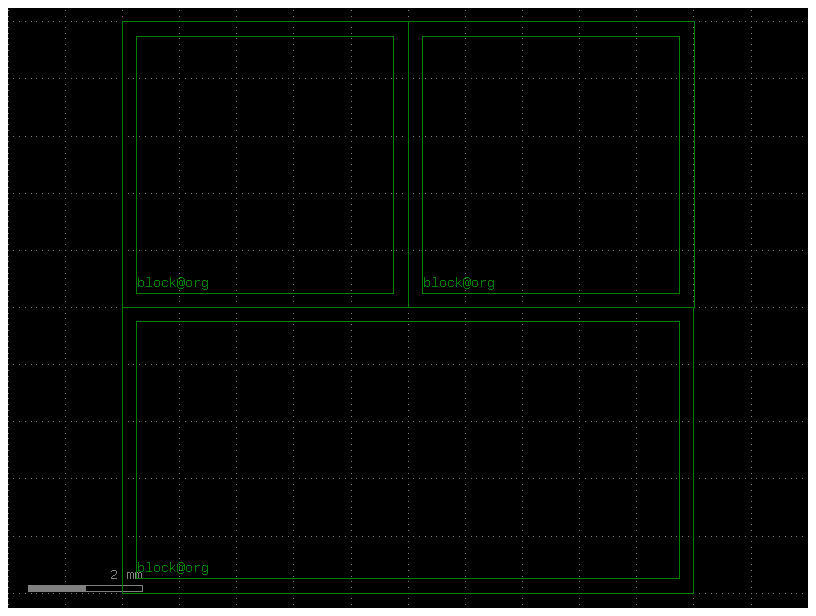

In [14]:
# 1. We define the cell as a function with it's corresponding parameters (and defaults)
gf.clear_cache()

@gf.cell
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):
    # Die specifications (Chip)
    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)
    # Adding ports to a component 
    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

# 2. We instantiate references of each cell. We can also name it individually to avoid problems
wafer = gf.Component()
dieW1 = 5000
dieW2 = 10000

c1 = wafer.add_ref(die(dieW = dieW1))
c2 = wafer.add_ref(die(dieW = dieW1))
c3 = wafer.add_ref(die(dieW = 10000))

c2.dmovex(dieW1)
c3.dmovey(-5000)
wafer.show()
wafer.plot()


- - Use your design results from Lab2 and Lab3 to create layout instances of your designed components: DCs, MMIs, MZIs & Ring Resonators”  Make cells for all your components. 

### A. Directional Couplers (DC)

2026-06-12 10:51:51.579 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


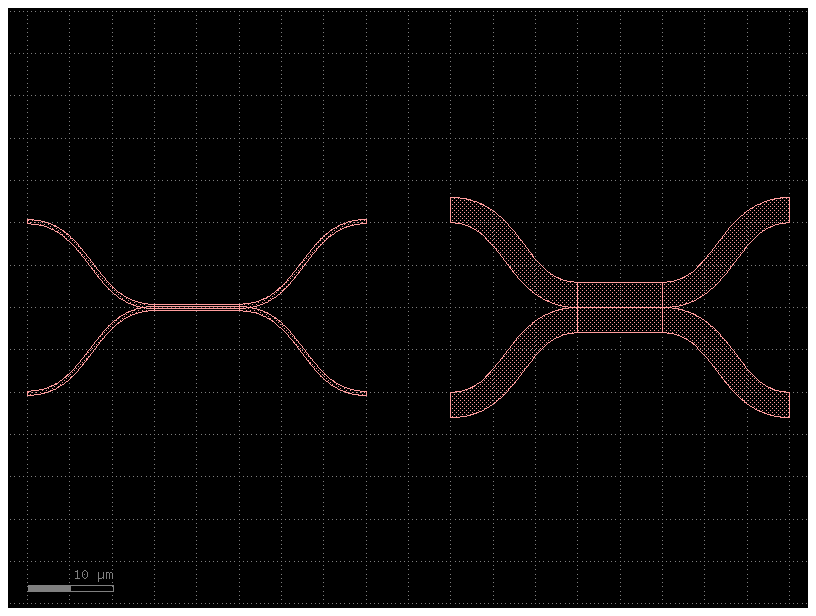

In [15]:
gf.clear_cache()
component_DC = gf.Component()

@gf.cell
def DC_cell(length=93.84, gap=0.5, width=0.5, layer="WG"):  

    c = gf.Component()
    xs_strip = gf.cross_section.strip(width=width, layer=layer)
    xs_io = gf.cross_section.strip(width=width, layer="WG")
    distancia_centros = width*gap  
    
    # GUIAS DE ONDA
    top_wvg = c.add_ref(gf.components.straight(length=length, cross_section=xs_strip)) 
    top_wvg.dmovey(distancia_centros / 2)
        
    bot_wvg = c.add_ref(gf.components.straight(length=length, cross_section=xs_strip)) 
    bot_wvg.dmovey(-distancia_centros / 2)
        
    # SALIDAS DEL ACOPLADOR
    s_bend = gf.components.bend_s(size=(15.0, 10.0), cross_section=xs_io)

    s_in_top = c.add_ref(s_bend).dmirror_y().connect("o2", top_wvg.ports["o1"])
    s_in_bot = c.add_ref(s_bend).connect("o2", bot_wvg.ports["o1"])

    s_out_top = c.add_ref(s_bend).connect("o1", top_wvg.ports["o2"])
    s_out_bot = c.add_ref(s_bend).dmirror_y().connect("o1", bot_wvg.ports["o2"])
    
    c.add_port(name="o1", port=s_in_bot.ports["o1"])   # Entrada Inferior Izquierda
    c.add_port(name="o2", port=s_in_top.ports["o1"])   # Entrada Superior Izquierda
    c.add_port(name="o3", port=s_out_top.ports["o2"])  # Salida Superior Derecha
    c.add_port(name="o4", port=s_out_bot.ports["o2"])  # Salida Inferior Derecha
    
    return c

dc_1 = component_DC.add_ref(DC_cell(length=10, gap=0.5)).dmovex(0).dmovey(0)
dc_1 = component_DC.add_ref(DC_cell(length=10, gap=1, width=3)).dmovex(50).dmovey(0)

component_DC.plot()
component_DC.show()

### B. Multi-Mode Interferometers (MMI)

2026-06-12 10:51:51.752 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


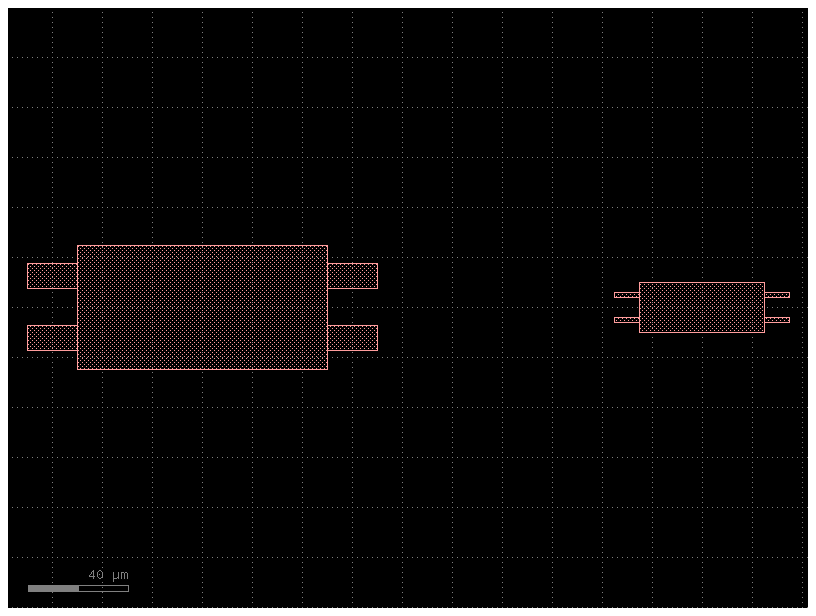

In [16]:
component_MMI = gf.Component()

@gf.cell
def MMI_cell(length_mmi=12.91, length_dc=10, width_mmi=6.0, io_width=1.0, width=0.5, layer='WG'):
    xs_strip = gf.cross_section.strip(width=width, layer=layer)
    xs_io = gf.cross_section.strip(width=io_width, layer="WG")

    c = gf.Component()
    
    cuerpo = c.add_ref(gf.components.rectangle(size=(length_mmi, width_mmi), layer=layer))
    cuerpo.dmovex(-length_mmi / 2).dmovey(-width_mmi / 2)
    
    straight_in1 = c.add_ref(gf.components.straight(length=length_dc, cross_section=xs_io))
    straight_in2 = c.add_ref(gf.components.straight(length=length_dc, cross_section=xs_io))
    straight_out1 = c.add_ref(gf.components.straight(length=length_dc, cross_section=xs_io))
    straight_out2 = c.add_ref(gf.components.straight(length=length_dc, cross_section=xs_io))
    
    x_entrada = -(length_mmi / 2) - length_dc
    straight_in1.dmovex(x_entrada).dmovey(width_mmi / 4)   # Entrada superior (o2)
    straight_in2.dmovex(x_entrada).dmovey(-width_mmi / 4)  # Entrada inferior (o1)
 
    x_salida = length_mmi / 2
    straight_out1.dmovex(x_salida).dmovey(width_mmi / 4)   # Salida superior (o3)
    straight_out2.dmovex(x_salida).dmovey(-width_mmi / 4)  # Salida inferior (o4)
    
    c.add_port(name="o1", port=straight_in2.ports["o1"])
    c.add_port(name="o2", port=straight_in1.ports["o1"])
    c.add_port(name="o3", port=straight_out1.ports["o2"])
    c.add_port(name="o4", port=straight_out2.ports["o2"])
    
    return c

cell_ref = component_MMI.add_ref(MMI_cell(length_mmi=100, length_dc=20, width_mmi=50.0, io_width=10.0, width=10, layer='WG')).dmovex(0).dmovey(0)
cell_ref = component_MMI.add_ref(MMI_cell(length_mmi=50, length_dc=10, width_mmi=20.0, io_width=2.0, width=10, layer='WG')).dmovex(200).dmovey(0)

component_MMI.plot()
component_MMI.show()

### C. Mach-Zehnder Interferometers (MZI)

2026-06-12 10:51:51.974 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


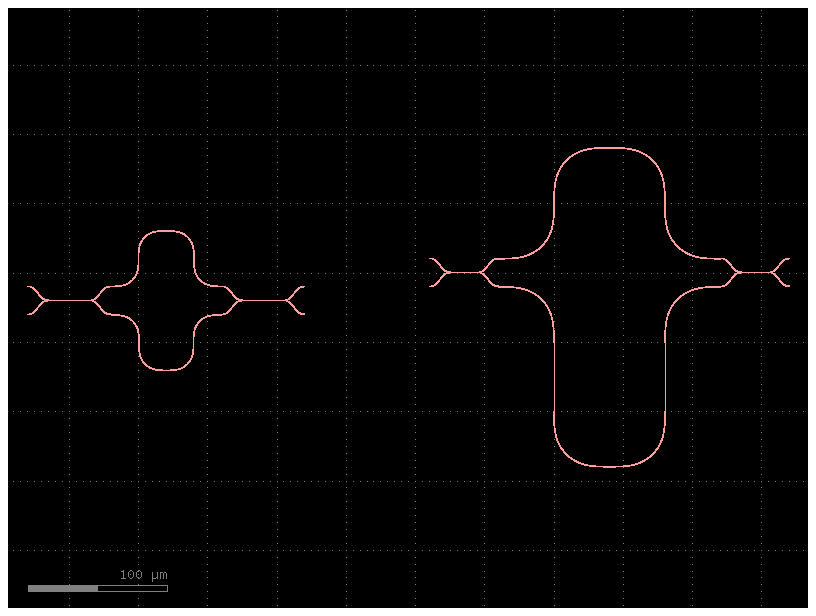

In [17]:
gf.clear_cache()
a2 = gf.Component()

@gf.cell
def MZI_cell(delta_length=40.0, radius=20.0, gap=0.5, length_dc=20.0, width=0.5, layer="WG"):

    xs_wg = gf.cross_section.strip(width=width, layer="WG")
    xs_heater = gf.cross_section.strip(width=width, layer="HEATER")
    c = gf.Component()

    # ANILLO SUPERIOR
    b1 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg))
    b2 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg))
    b3 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg))
    b4 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg))

    b1.drotate(270).dmovey(2*radius+20+gap).dmovex(2*radius)
    b2.connect("o1", b1.ports["o1"])
    b3.connect("o1", b2.ports["o2"])
    b4.connect("o2", b3.ports["o2"])

    # ANILLO INFERIOR
    b5 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg))
    b6 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg))
    b7 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_wg))
    b8 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip if 'xs_strip' in locals() else xs_wg)) 

    v_left = c.add_ref(gf.components.straight(length=delta_length, cross_section=xs_wg))
    v_right = c.add_ref(gf.components.straight(length=delta_length, cross_section=xs_wg))

    b5.drotate(90)
    v_left.drotate(90).connect("o2", b5.ports["o1"])
    b6.connect("o1", v_left.ports["o1"])
    b7.connect("o1", b6.ports["o2"])
    v_right.drotate(90).connect("o1", b7.ports["o2"])
    b8.connect("o2", v_right.ports["o2"])

    # ACOPLADORES
    dc_right = c.add_ref(DC_cell(length=length_dc, gap=gap, width=width))
    dc_left = c.add_ref(DC_cell(length=length_dc, gap=gap, width=width))

    dc_right.connect("o1", b8.ports["o1"]).connect("o2", b1.ports["o2"])
    dc_left.connect("o3", b4.ports["o1"]).connect("o4", b5.ports["o2"])
    
    # =========================================================================
    # EN CASO DE USAR EL HEATER
    # =========================================================================
    if layer == "HEATER":
        # Duplicamos el Anillo Superior en capa HEATER conectándolo a los mismos sitios
        h_b1 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_heater))
        h_b1.drotate(270).dmovey(2*radius+20+gap).dmovex(2*radius) # Sigue la misma posición inicial que b1
        
        h_b2 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_heater)).connect("o1", h_b1.ports["o1"])
        h_b3 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_heater)).connect("o1", h_b2.ports["o2"])
        h_b4 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_heater)).connect("o2", h_b3.ports["o2"])

        # Duplicamos el Anillo Inferior en capa HEATER
        h_b5 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_heater)).drotate(90)
        
        h_v_left = c.add_ref(gf.components.straight(length=delta_length, cross_section=xs_heater)).connect("o2", h_b5.ports["o1"])
        h_b6 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_heater)).connect("o1", h_v_left.ports["o1"])
        h_b7 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_heater)).connect("o1", h_b6.ports["o2"])
        h_v_right = c.add_ref(gf.components.straight(length=delta_length, cross_section=xs_heater)).connect("o1", h_b7.ports["o2"])
        h_b8 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_heater)).connect("o2", h_v_right.ports["o2"])

    
    c.add_port(name="o1", port=dc_left.ports["o1"])
    c.add_port(name="o2", port=dc_left.ports["o2"])
    c.add_port(name="o3", port=dc_right.ports["o3"])
    c.add_port(name="o4", port=dc_right.ports["o4"])

    return c

mzi_heater = a2.add_ref(MZI_cell(delta_length=0.0, radius=20.0, gap=0.5, length_dc=30.0, width=0.5, layer="WG")).dmovex(0).dmovey(0)
mzi_heater = a2.add_ref(MZI_cell(delta_length=50.0, radius=40.0, gap=0.5, length_dc=20.0, width=0.5, layer="WG")).dmovex(300).dmovey(0)

a2.plot()
a2.show()

### D. Ring Resonators

2026-06-12 10:51:52.138 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


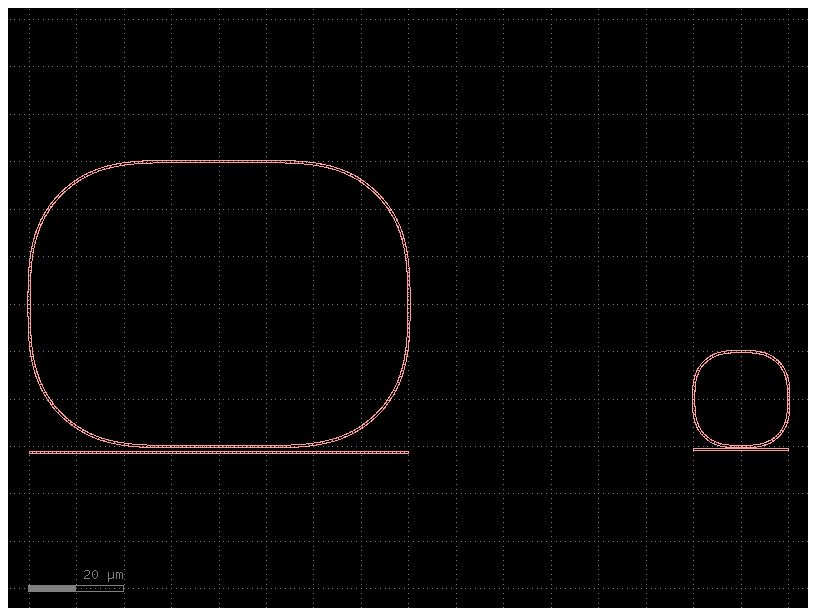

In [18]:
component_RING = gf.Component()

@gf.cell
def RING_cell(radius=20.0, gap=0.2, width=0.5, length=10.0, layer='WG'):
    xs_strip = gf.cross_section.strip(width=width, layer=layer)
    xs_io = gf.cross_section.strip(width=width, layer="WG")
    c = gf.Component()
    
   
    b1 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip))
    b2 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip)).connect("o1", b1.ports["o2"])
    v_straight_right = c.add_ref(gf.components.straight(length=length, cross_section=xs_strip)).connect("o1", b2.ports["o2"])
    b3 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip)).connect("o1", v_straight_right.ports["o2"])
    b4 = c.add_ref(gf.components.bend_euler(radius=radius, angle=90, cross_section=xs_strip)).connect("o1", b3.ports["o2"])
    v_straight_left = c.add_ref(gf.components.straight(length=length, cross_section=xs_strip)).connect("o1", b4.ports["o2"])

    bus_length = 2 * radius + length
    v_straight = c.add_ref(gf.components.straight(length=bus_length, cross_section=xs_io))
    
    y_bus = b1.ports["o1"].center[1] - (gap + width)
    x_bus = b4.ports["o1"].center[0] 
    
    v_straight.dmovex(x_bus).dmovey(y_bus)

    c.add_port(name="o1", port=v_straight.ports["o1"])
    c.add_port(name="o2", port=v_straight.ports["o2"])

    return c

ring_1 = component_RING.add_ref(RING_cell(radius=30.0, gap=0.8, length=20.0)).dmovex(0).dmovey(0)
ring_1 = component_RING.add_ref(RING_cell(radius=10.0, gap=0.2, length=0.0)).dmovex(100).dmovey(0)

component_RING.plot()
component_RING.show()

## 3. Complete Layout

2026-06-12 10:51:52.333 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


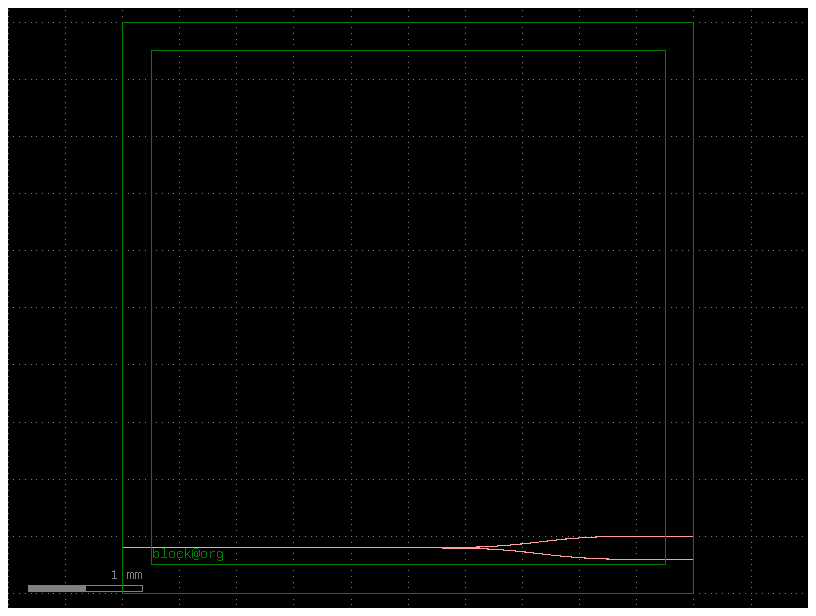

In [19]:
layer_wg  = "WG"
minrad = 50
dieW = 5000

main = gf.Component()

die_ref = main.add_ref(die(dieW = dieW, layer_box="FLOORPLAN"))

## Add first a test MMI routed from side to side
c_mmi = cells.mmi1x2()
mmi = main.add_ref(c_mmi)
mmi.dmovex(die_ref["block@org"].dx + 0.5*dieW).dmovey(die_ref['block@org'].dy + 150)

## Route waveguides from MMI to the die edges
xs = 'strip'
### First add the i/o waveguides - to be sure you 'cut' on a straight section
strin = (main.add_ref(gf.components.straight(length=500, cross_section='strip')).dmovex(0).dmovey(mmi['o1'].dy))
strout1 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o3'].dy-100).dmovex(dieW))
strout2 = (main.add_ref(gf.components.straight(length=500, cross_section=xs)).drotate(180).dmovey(mmi.ports['o2'].dy+100).dmovex(dieW))

### Then route from the i/o waveguides to the MMI
gf.routing.route_single_sbend(main,port1=strin['o2'], port2=mmi['o1'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o2'], port2=strout2['o2'], cross_section=xs)
gf.routing.route_single_sbend(main,port1=mmi['o3'], port2=strout1['o2'], cross_section=xs)

main.plot()
main.show()

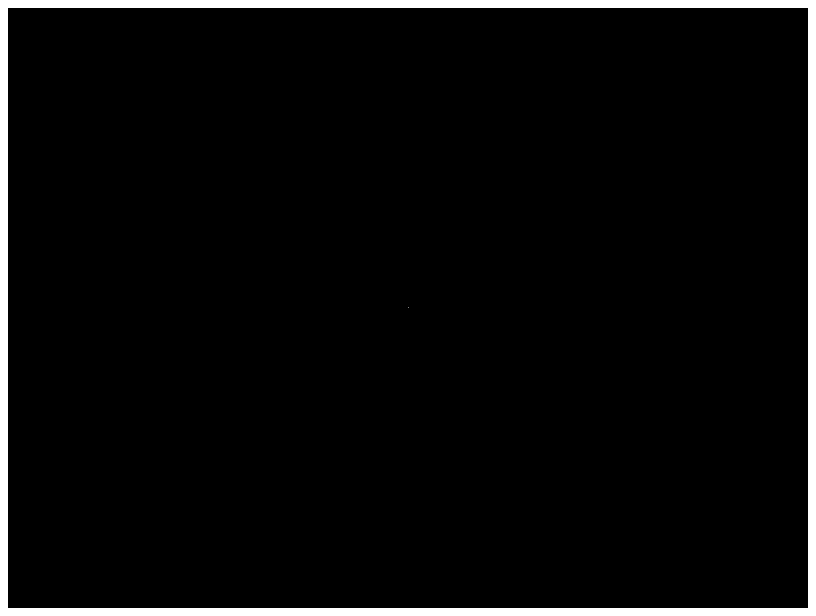

In [20]:
# Let's create a MMI tree

c = gf.Component()
c_mmi = cells.mmi1x2()
...
c.plot()

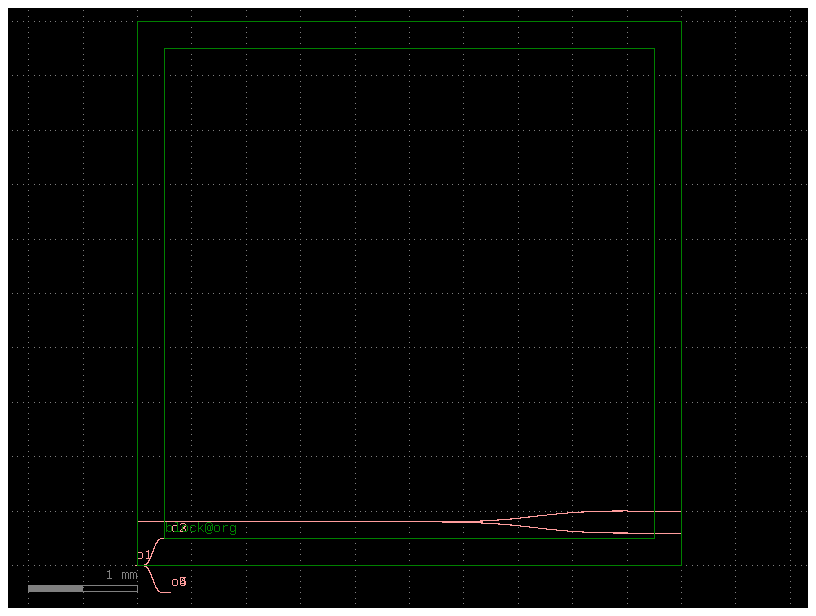

In [21]:
# Once we "test" the high-level component, we can create a cell for it
@gf.cell 
def mmi_tree_1x4(pad_x = 250 ,pad_y = 250):
    c = gf.Component()
    c_mmi = cells.mmi1x2()
    mmi1 = c.add_ref(c_mmi)
    mmi2 = c.add_ref(c_mmi)
    mmi3 = c.add_ref(c_mmi)

    mmi2.dmovex(pad_x).dmovey(pad_y)
    mmi3.dmovex(pad_x).dmovey(-pad_y)

    gf.routing.route_single_sbend(component=c, port1= mmi1['o2'], port2=mmi2['o1'],cross_section='strip')
    gf.routing.route_single_sbend(component=c, port1= mmi1['o3'], port2=mmi3['o1'],cross_section='strip')
    c.add_port(name='o1', port=mmi1['o1'])
    c.add_port(name='o2', port=mmi2['o2'])
    c.add_port(name='o3', port=mmi2['o3'])
    c.add_port(name='o4', port=mmi3['o2'])
    c.add_port(name='o5', port=mmi3['o3'])
    c.draw_ports()
    return c

# With the cell created, we can instantiate and use it in our main component

cell_1x4 = main.add_ref(mmi_tree_1x4())
main.plot()

2026-06-12 10:51:52.749 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


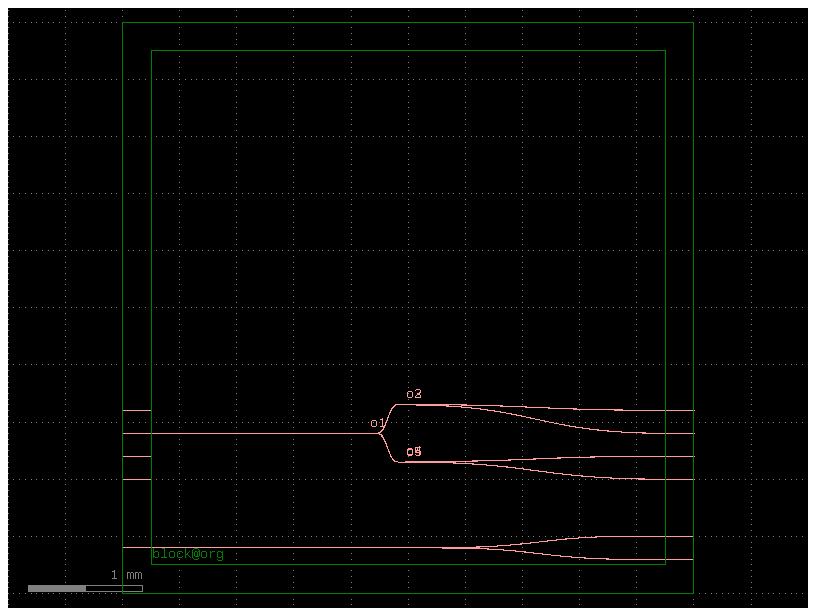

In [22]:
## Arrayed waveguides and MMI tree
sp = 200
border = 250

in_arr = main.add_ref(
    gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
).dmovey(
    1000
)  #!!!!!! Easy to put IO Waveguides for a complete design !!!!

out_arr = (
    main.add_ref(
        gf.components.straight_array(n=4, spacing=sp, length=border, cross_section=xs)
    )
    .dmovex(dieW - border)
    .dmovey(1000)
)

cell_1x4.dmovex(0.5*dieW - mmi_tree_1x4().dxsize).dmovey(in_arr['o6'].dy)
gf.routing.route_single_sbend(component=main, port1=in_arr['o6'], port2=cell_1x4['o1'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o2'], port2=out_arr['o4'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o3'], port2=out_arr['o3'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o4'], port2=out_arr['o2'])
gf.routing.route_single_sbend(component=main, port1=cell_1x4['o5'], port2=out_arr['o1'])
main.plot()
main.show()

2026-06-12 10:51:52.956 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


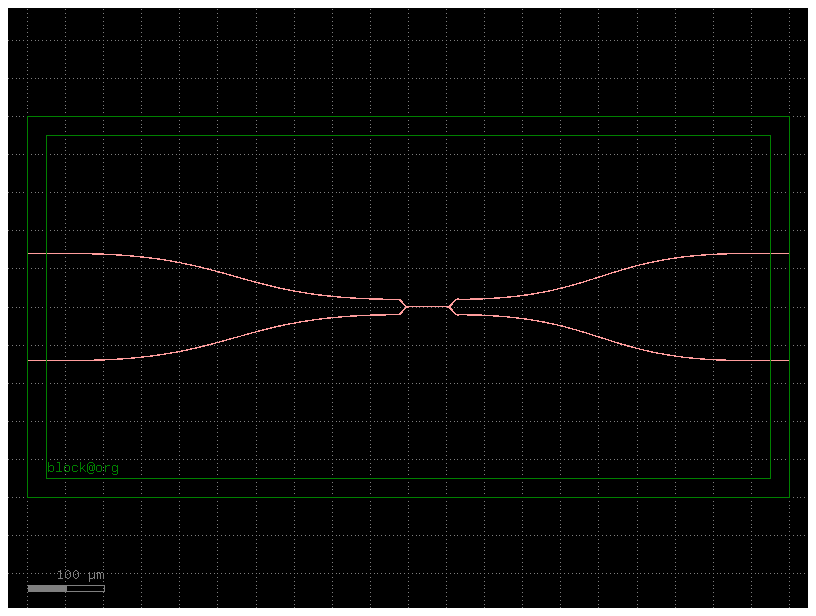

In [23]:
DC_wafer = gf.Component()

dieW = 1000
dieL = 500
border = 25
width=0.5
xs = gf.cross_section.strip(width=width, layer="WG")

die_ref = DC_wafer.add_ref(die(dieW=dieW, dieL=dieL, border=border, layer_box="FLOORPLAN"))

cell_ref = DC_wafer.add_ref(DC_cell(length=50.0, gap=0.5, width=width)).dmovex(500).dmovey(250)

strin1 = DC_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).dmovex(0).dmovey(cell_ref['o2'].dy + 60)
strin2 = DC_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).dmovex(0).dmovey(cell_ref['o1'].dy - 60)

strout1 = DC_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).drotate(180).dmovex(dieW).dmovey(cell_ref['o3'].dy + 60)
strout2 = DC_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).drotate(180).dmovex(dieW).dmovey(cell_ref['o4'].dy - 60)

gf.routing.route_single_sbend(DC_wafer, port1=strin1['o2'], port2=cell_ref['o2'], cross_section=xs)
gf.routing.route_single_sbend(DC_wafer, port1=strin2['o2'], port2=cell_ref['o1'], cross_section=xs)

gf.routing.route_single_sbend(DC_wafer, port2=cell_ref['o3'], port1=strout1['o2'], cross_section=xs)
gf.routing.route_single_sbend(DC_wafer, port2=cell_ref['o4'], port1=strout2['o2'], cross_section=xs)

DC_wafer.plot()
DC_wafer.show()

2026-06-12 10:51:53.157 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


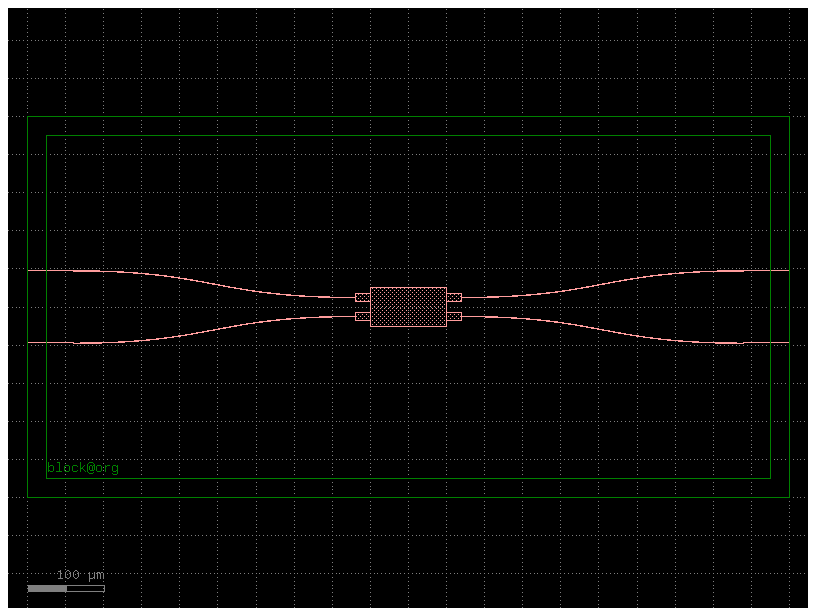

In [24]:
MMI_wafer = gf.Component()

dieW = 1000; dieL = 500; border = 25; 
xs = gf.cross_section.strip(width=width, layer="WG")

die_ref = MMI_wafer.add_ref(die(dieW=dieW, dieL=dieL, border=border, layer_box="FLOORPLAN"))

cell_ref = MMI_wafer.add_ref(MMI_cell(length_mmi=100, length_dc=20, width_mmi=50.0, io_width=10.0, width=10, layer='WG')).dmovex(500).dmovey(250)

strin1 = MMI_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).dmovex(0).dmovey(cell_ref['o1'].dy + 60)
strin2 = MMI_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).dmovex(0).dmovey(cell_ref['o2'].dy - 60)

strout1 = MMI_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).drotate(180).dmovex(dieW).dmovey(cell_ref['o4'].dy + 60)
strout2 = MMI_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).drotate(180).dmovex(dieW).dmovey(cell_ref['o3'].dy - 60)

# Conexiones de Entrada (Lado Izquierdo)
gf.routing.route_single_sbend(MMI_wafer, port1=strin1['o2'], port2=cell_ref['o2'], cross_section=xs)
gf.routing.route_single_sbend(MMI_wafer, port1=strin2['o2'], port2=cell_ref['o1'], cross_section=xs)

# Conexiones de Salida (Lado Derecho)
gf.routing.route_single_sbend(MMI_wafer, port2=cell_ref['o3'], port1=strout1['o2'], cross_section=xs)
gf.routing.route_single_sbend(MMI_wafer, port2=cell_ref['o4'], port1=strout2['o2'], cross_section=xs)

# ========================================================
# PASO 5: Visualización
# ========================================================
MMI_wafer.plot()
MMI_wafer.show()

2026-06-12 10:51:53.405 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


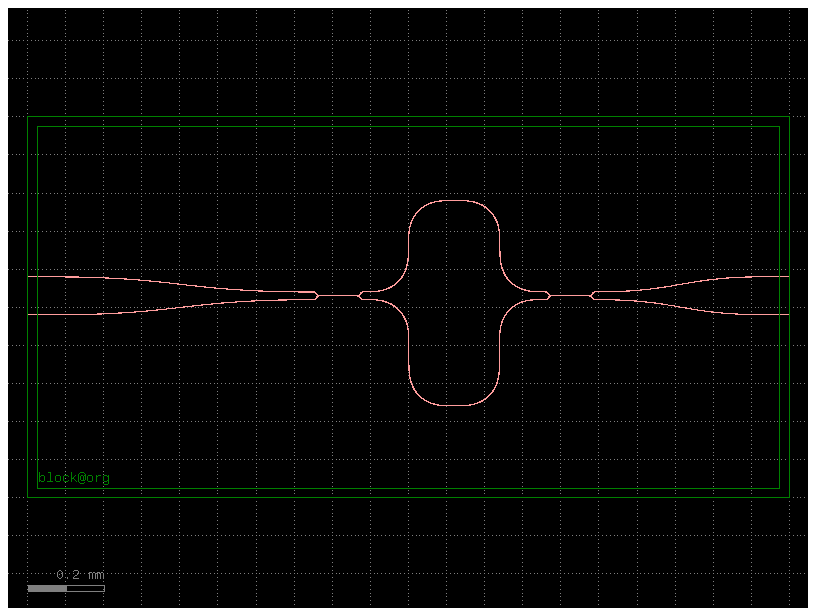

In [25]:
MZI_wafer = gf.Component()

dieW = 2000; dieL = 1000; border = 25; width=0.5
xs = gf.cross_section.strip(width=width, layer="WG")

die_ref = MZI_wafer.add_ref(die(dieW=dieW, dieL=dieL, border=border, layer_box="FLOORPLAN")).dmovex(0).dmovey(-300)
cell_ref = MZI_wafer.add_ref(MZI_cell(delta_length=40.0, radius=120.0, gap=0.5, length_dc=100.0, width=width, layer="WG")).dmovex(1000).dmovey(100)


strin1 = MZI_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).dmovex(0).dmovey(cell_ref['o1'].dy + 60)
strin2 = MZI_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).dmovex(0).dmovey(cell_ref['o2'].dy - 60)
strout1 = MZI_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).drotate(180).dmovex(dieW).dmovey(cell_ref['o4'].dy + 60)
strout2 = MZI_wafer.add_ref(gf.components.straight(length=60, cross_section=xs)).drotate(180).dmovex(dieW).dmovey(cell_ref['o3'].dy - 60)

gf.routing.route_single_sbend(MZI_wafer, port1=strin1['o2'], port2=cell_ref['o2'], cross_section=xs)
gf.routing.route_single_sbend(MZI_wafer, port1=strin2['o2'], port2=cell_ref['o1'], cross_section=xs)
gf.routing.route_single_sbend(MZI_wafer, port2=cell_ref['o3'], port1=strout1['o2'], cross_section=xs)
gf.routing.route_single_sbend(MZI_wafer, port2=cell_ref['o4'], port1=strout2['o2'], cross_section=xs)

MZI_wafer.plot()
MZI_wafer.show()

2026-06-12 10:51:53.608 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


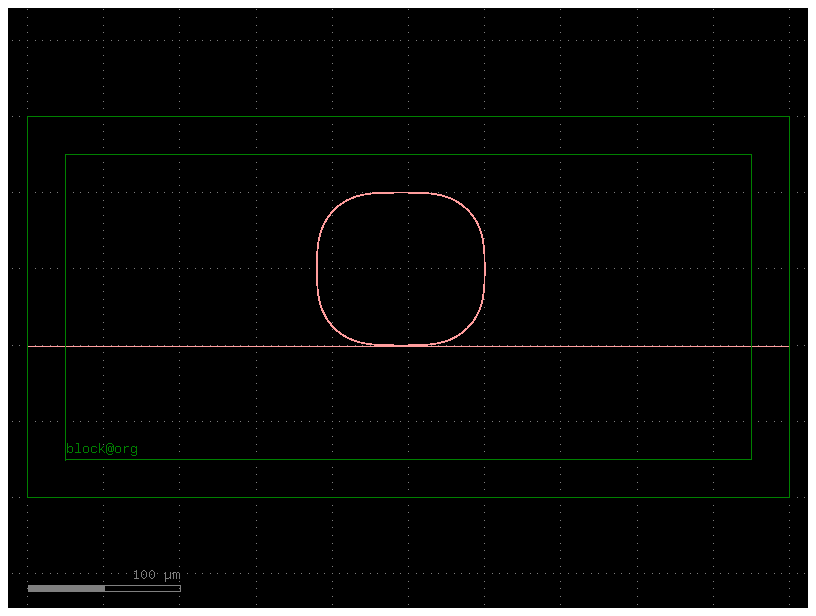

In [26]:
RING_wafer = gf.Component()

dieW = 500; dieL = 250; border = 25; 

xs_clean = gf.cross_section.strip(width=0.5, layer='WG')

die_ref = RING_wafer.add_ref(die(dieW=dieW, dieL=dieL, border=border, layer_box="FLOORPLAN")).dmovex(0).dmovey(0)
cell_ref = RING_wafer.add_ref(RING_cell(radius=50.0, gap=0.2, width=0.5, layer='WG')).dmovex(250).dmovey(100)

strin1 = RING_wafer.add_ref(gf.components.straight(length=10, cross_section=xs_clean)).dmovex(0).dmovey(cell_ref['o1'].dy)
strout1 = RING_wafer.add_ref(gf.components.straight(length=10, cross_section=xs_clean)).drotate(180).dmovex(dieW).dmovey(cell_ref['o2'].dy)

gf.routing.route_single_sbend(RING_wafer, port1=strin1['o2'], port2=cell_ref['o1'], cross_section=xs_clean)
gf.routing.route_single_sbend(RING_wafer, port1=cell_ref['o2'], port2=strout1['o2'], cross_section=xs_clean)

RING_wafer.plot()
RING_wafer.show()

### Mantra:
It's useful to use memorize this mantra: 
- Add_references 
- Connect_them
- Move_them

### Other Routing options examples:

Please check the GDSFactory Routing API for more information about advanced routing functionalities

[Routing API](https://gdsfactory.github.io/gdsfactory/api_routing.html) 

## 4. Exercises. 

Part a) Creating components
- Create a cell component for a unbalanced MZI, using 2x2 50:50 MMIs with arm length difference as parameter

2026-06-12 10:51:53.784 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


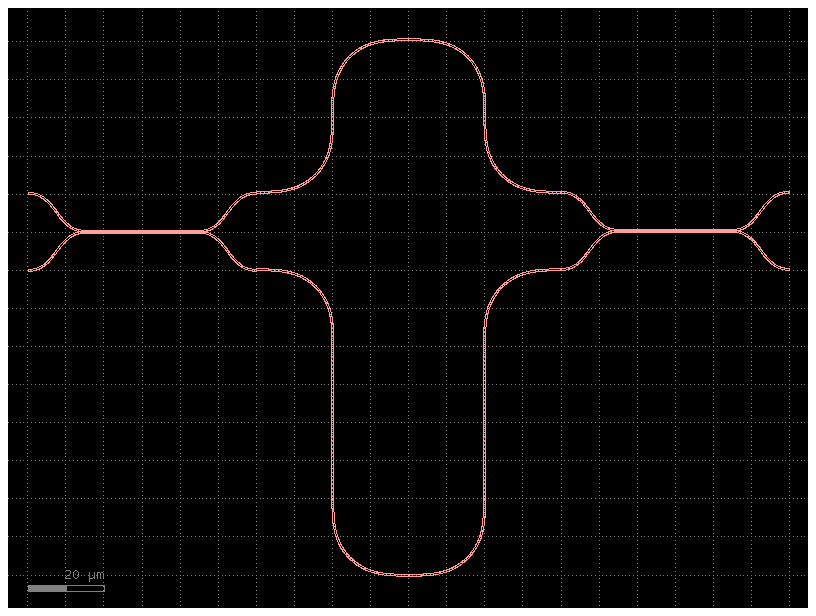

In [27]:
a1 = gf.Component()

mzi=a1.add_ref(MZI_cell(delta_length=40.0, radius=20.0, gap=0.5, length_dc=30.0, width=0.5, layer="WG")).dmovex(0).dmovey(0)

a1.plot()
a1.show()

- Create a cell component based on the previous, where the arms have thermal tuners on top of each one

2026-06-12 10:51:54.017 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


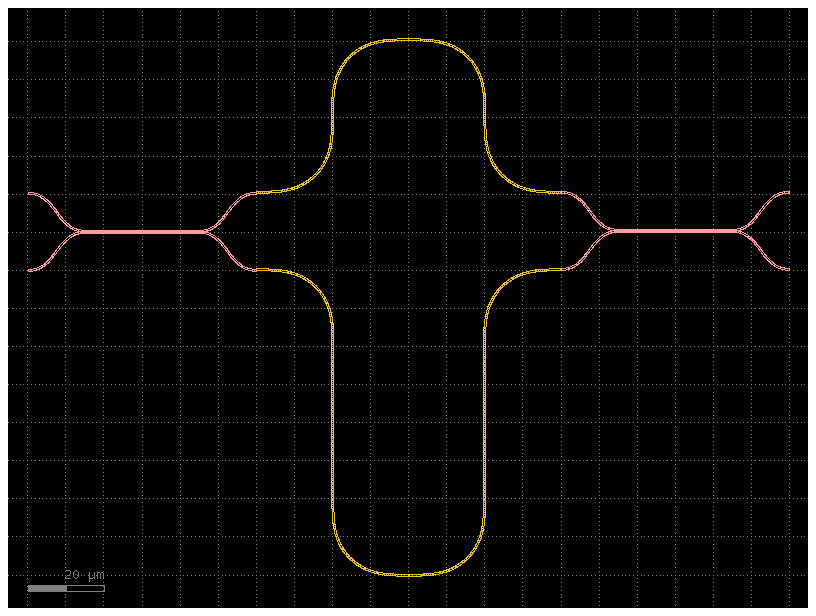

In [28]:
a2 = gf.Component()

mzi_heater=a2.add_ref(MZI_cell(delta_length=40.0, radius=20.0, gap=0.5, length_dc=30.0, width=0.5, layer="HEATER")).dmovex(0).dmovey(0)

a2.plot()
a2.show()

- Create a cell component for an all-pass ring resonator, using 2x2 50:50 MMIs, with extra length parameter for different perimeters

2026-06-12 10:51:54.187 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


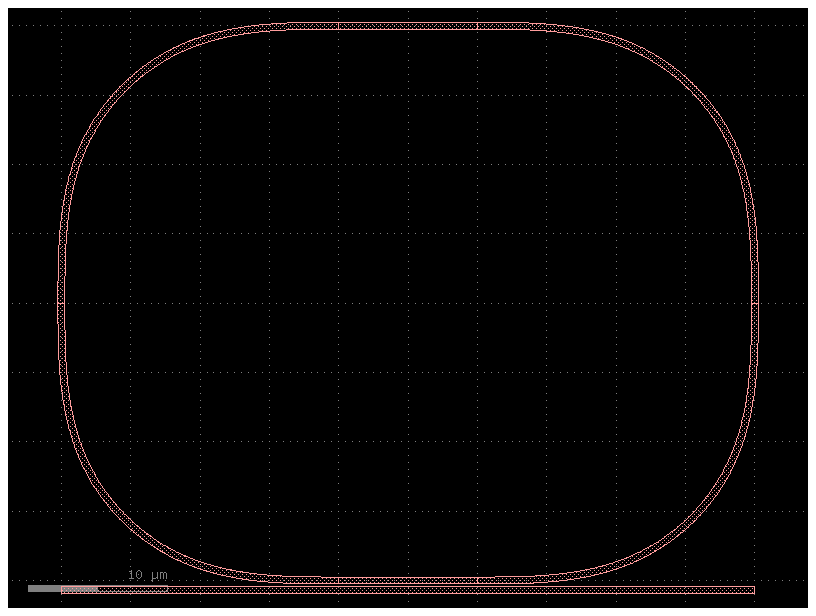

In [29]:
a3 = gf.Component()

ring = a3.add_ref(RING_cell(radius=20.0, gap=0.2, width=0.5, layer='WG'))

a3.plot()
a3.show()

- Create a cell component based on the previous, where the ring has a thermal tuner on top along all the perimeter

2026-06-12 10:51:54.351 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


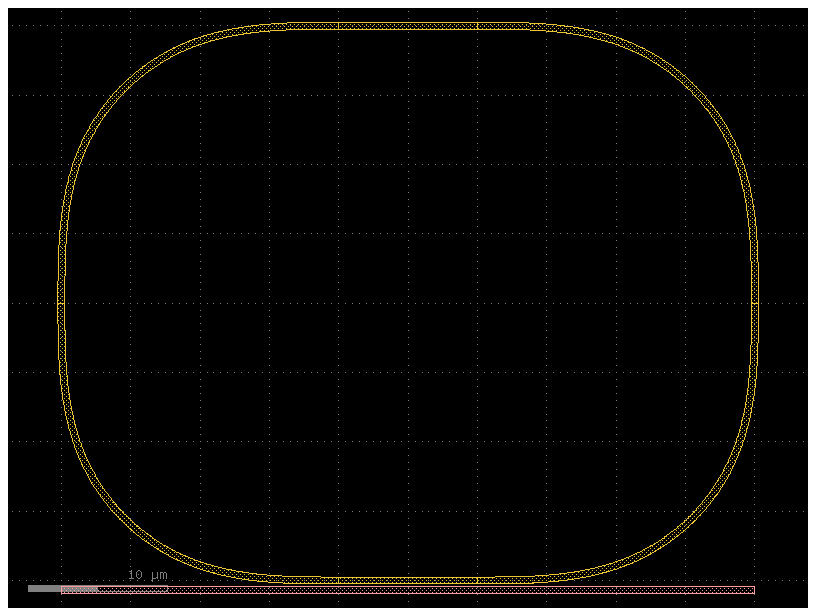

In [30]:
a4 = gf.Component()

ring_heater = a4.add_ref(RING_cell(radius=20.0, gap=0.2, width=0.5, layer='HEATER'))

a4.plot()
a4.show()

- Create a cell component based on existing GDSfactory spiral components, with length as parameter

2026-06-12 10:51:54.564 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


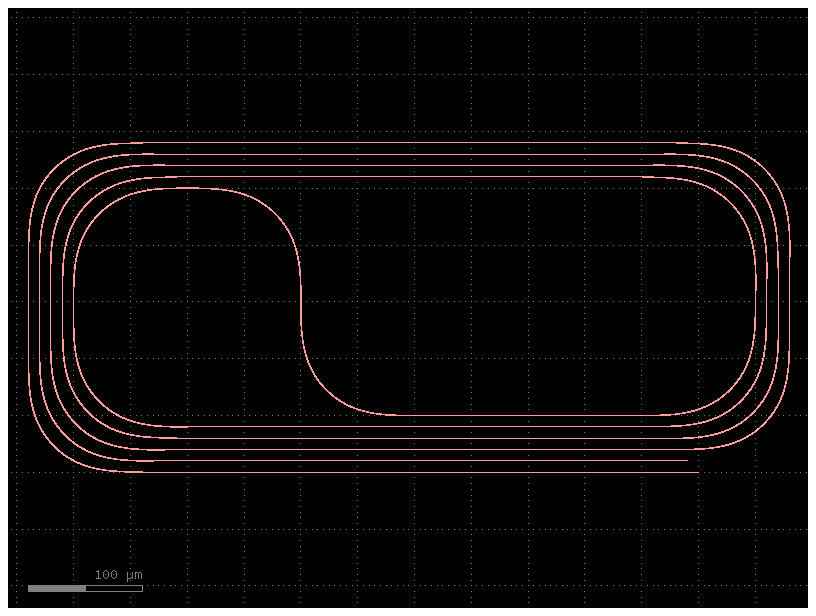

In [31]:
@gf.cell
def SPIRAL_cell(length=200.0, n_loops=5, spacing=10.0, width=0.5):
    c = gf.Component()
    
    # 1. Obtenemos la definición base de "strip" y le sobreescribimos el ancho (width)
    # Esto respeta las capas (layers) y configuraciones que tenga "strip" en tu tecnología actual.
    xs_custom = gf.get_cross_section("strip", width=width)
    
    # 2. Se lo pasamos a la espiral forzando los subcomponentes como antes
    spiral_cell = gf.components.spiral(
        length=length, 
        n_loops=n_loops, 
        spacing=spacing, 
        cross_section=xs_custom,
        straight=gf.components.straight,  
        bend=gf.components.bend_euler    
    )
    
    spiral_ref = c.add_ref(spiral_cell)
    c.add_ports(spiral_ref.ports)
    return c

a5 = gf.Component()

spiral = a5.add_ref(SPIRAL_cell(length=200.0, n_loops=5, spacing=10.0)).dmovex(0).dmovey(0)
a5.plot()
a5.show()

Part b) Creating die
- Create a die  W = 5 mm x L = 10 mm 

2026-06-12 10:51:54.684 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


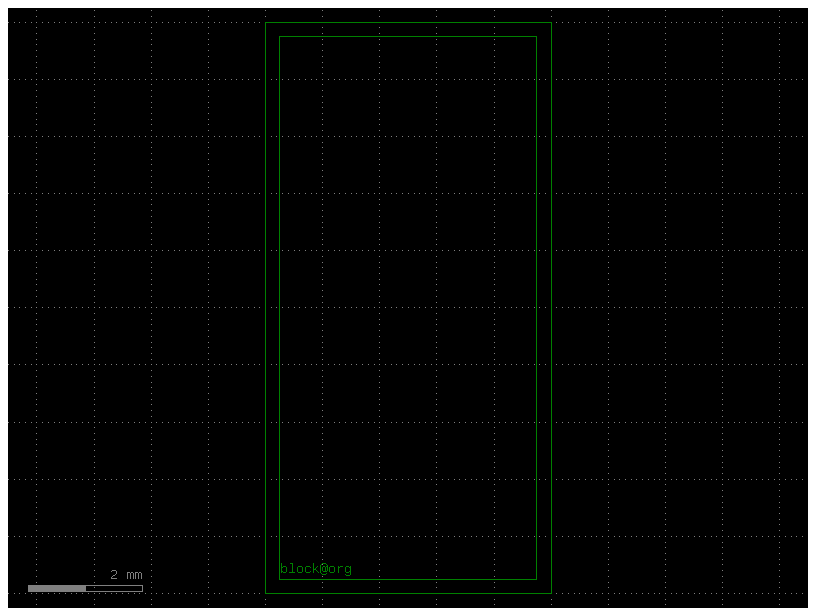

In [32]:
new_die = gf.Component()
die = new_die.add_ref(die(dieW = 5000, dieL=10000))
new_die.show()
new_die.plot()

- Create an array of I/Os spaced at 250 µm (as much I/Os as the width allows)

2026-06-12 10:51:54.831 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


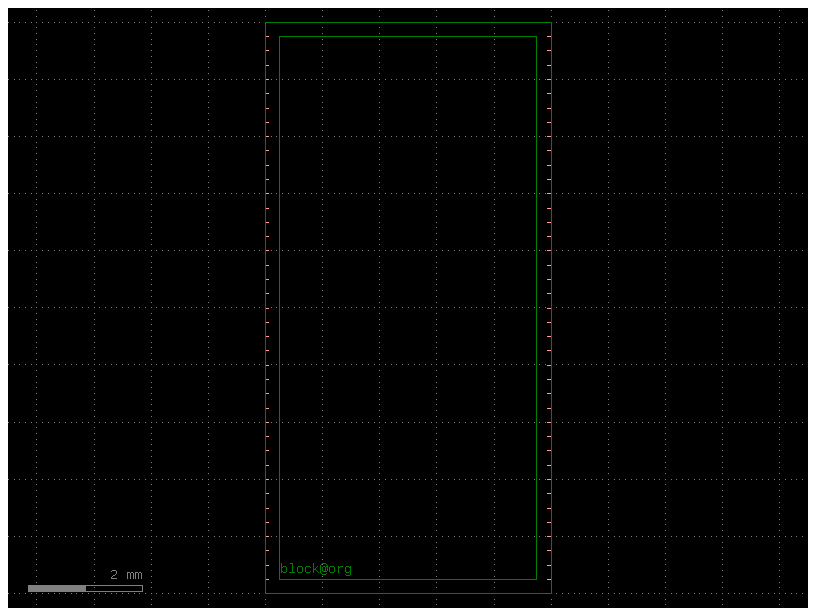

In [33]:
die_ios = gf.Component()
die_cell = die_ios.add_ref(new_die)
xs = gf.cross_section.strip(width=0.5, layer="WG")
spacing = 250.0
io_length = 60.0
border = 250  

# Acceso correcto a los límites espaciales del componente referenciado
xmin = die_cell.xmin
xmax = die_cell.xmax
ymin = die_cell.ymin
ymax = die_cell.ymax


alto_util = ymax - ymin

num_ios = int(alto_util // spacing) 

for i in range(num_ios):
    y_pos = ymin + border + (i * spacing)
    
    if y_pos > (ymax - border):
        break
        
    strin = die_ios.add_ref(gf.components.straight(length=io_length, cross_section=xs))
    strin.dmovex(xmin).dmovey(y_pos)
    
    strout = die_ios.add_ref(gf.components.straight(length=io_length, cross_section=xs))
    strout.drotate(180).dmovex(xmax).dmovey(y_pos)

die_ios.show()
die_ios.plot()

- Create a cell component of this die, with I/Os accessible to connect

In [34]:
@gf.cell
def die_with_ios(): 

    die_ios = gf.Component()
    die_cell = die_ios.add_ref(new_die)

    xmin = die_cell.xmin
    xmax = die_cell.xmax
    ymin = die_cell.ymin
    ymax = die_cell.ymax

    alto_util = ymax - ymin

    num_ios = int(alto_util // spacing) 

    for i in range(num_ios):
        y_pos = ymin + border + (i * spacing)
        
        if y_pos > (ymax - border):
            break
            
        strin = die_ios.add_ref(gf.components.straight(length=io_length, cross_section=xs)).dmovex(xmin).dmovey(y_pos)
        die_ios.add_port(name=f"in_{i}", port=strin.ports['o2'])

        strout = die_ios.add_ref(gf.components.straight(length=io_length, cross_section=xs)).drotate(180).dmovex(xmax).dmovey(y_pos)
        die_ios.add_port(name=f"out_{i}", port=strout.ports['o2'])

        #die_ios.draw_ports()
    return die_ios

Part c) Floorplaning and die layout
- Make an instance of the die as host component for your layout

In [35]:
layout_final = gf.Component()
die_instancia = layout_final.add_ref(die_with_ios())

- Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die

In [36]:
guia_recta_low = layout_final.add_ref(gf.components.straight(length=dieW, cross_section=xs)).dmovex(0).dmovey(2500)
guia_recta_middle = layout_final.add_ref(gf.components.straight(length=dieW, cross_section=xs)).dmovex(0).dmovey(5000)
guia_recta_top = layout_final.add_ref(gf.components.straight(length=dieW, cross_section=xs)).dmovex(0).dmovey(7500)

- Add 2 of each of the components above, with different lengths

- Connect all your components to the I/Os 

2026-06-12 10:54:04.025 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


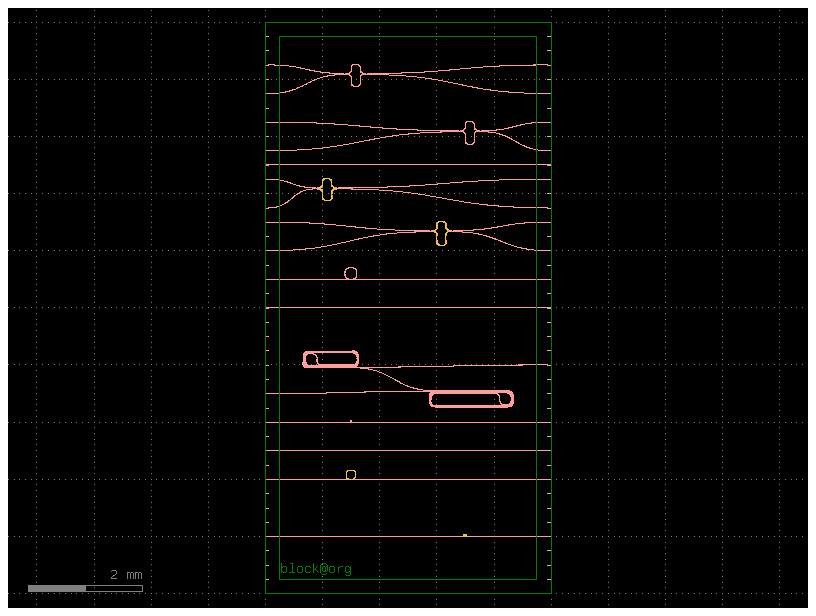

In [39]:
# ========================================================
# Make an instance of the die as host component for your layout
# ========================================================
layout_final = gf.Component()

dieW = 5000; dieL = 5000  ; border = 250; spacing = 250.0; io_length = 60.0
xs = gf.cross_section.strip(width=0.5, layer="WG")
xs_spiral = gf.get_cross_section("strip", width=0.5)
die_instancia = layout_final.add_ref(die_with_ios())

# ========================================================
# Add 2 of each of the components above, with different lengths
# ========================================================
mzi_1 = layout_final.add_ref(MZI_cell(delta_length=40.0, radius=80.0, gap=0.5, length_dc=30.0, width=0.5, layer="WG")).dmovex(1500).dmovey(9000)
mzi_2 = layout_final.add_ref(MZI_cell(delta_length=60.0, radius=80.0, gap=0.5, length_dc=30.0, width=0.5, layer="WG")).dmovex(3500).dmovey(8000)
mzi_heater_1 = layout_final.add_ref(MZI_cell(delta_length=50.0, radius=80.0, gap=0.5, length_dc=30.0, width=0.5, layer="HEATER")).dmovex(1000).dmovey(7000)
mzi_heater_2 = layout_final.add_ref(MZI_cell(delta_length=80.0, radius=80.0, gap=0.5, length_dc=30.0, width=0.5, layer="HEATER")).dmovex(3000).dmovey(6250)
spiral_1 = layout_final.add_ref(SPIRAL_cell(length=1000.0, n_loops=5)).dmovex(-4000).dmovey(-3500).drotate(180)
spiral_2 = layout_final.add_ref(SPIRAL_cell(length=500.0, n_loops=5)).dmovex(1000).dmovey(4000).drotate(0)
ring_1 = layout_final.add_ref(RING_cell(radius=100.0, gap=0.2, width=1.0, layer='WG')).dmovex(1500).dmovey(5500)
ring_2 = layout_final.add_ref(RING_cell(radius=10.0, gap=0.2, width=1.0, layer='WG')).dmovex(1500).dmovey(3000)
ring_heater_1 = layout_final.add_ref(RING_cell(radius=80.0, gap=0.2, width=1.0, layer='HEATER')).dmovex(1500).dmovey(2000)
ring_heater_2 = layout_final.add_ref(RING_cell(radius=20.0, gap=0.2, width=1.0, layer='HEATER')).dmovex(3500).dmovey(1000)

# ========================================================
# Add 3 sets of 3 straight waveguides, from left to right of the die, top, middle and bottom of the die
# ========================================================
guia_recta_low = layout_final.add_ref(gf.components.straight(length=dieW, cross_section=xs)).dmovex(0).dmovey(2500)
guia_recta_middle = layout_final.add_ref(gf.components.straight(length=dieW, cross_section=xs)).dmovex(0).dmovey(5000)
guia_recta_top = layout_final.add_ref(gf.components.straight(length=dieW, cross_section=xs)).dmovex(0).dmovey(7500)

# ========================================================
# PASO 5: Enrutamiento Automático de Componentes a los I/Os
# ========================================================

# RUTADO PARA LOS DOS PRIMEROS MZI (Altura ~9000)
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_36"], port2=mzi_1.ports['o2'],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_34"], port2=mzi_1.ports['o1'],  cross_section=xs)

gf.routing.route_single_sbend(layout_final, port2=mzi_1.ports['o3'], port1=die_instancia.ports["out_36"],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port2=mzi_1.ports['o4'], port1=die_instancia.ports["out_34"],  cross_section=xs)

gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_32"], port2=mzi_2.ports['o2'],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_30"], port2=mzi_2.ports['o1'],  cross_section=xs)

gf.routing.route_single_sbend(layout_final, port2=mzi_2.ports['o3'], port1=die_instancia.ports["out_32"],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port2=mzi_2.ports['o4'], port1=die_instancia.ports["out_30"],  cross_section=xs)


# RUTADO PARA LOS MZI CON HEATER
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_28"], port2=mzi_heater_1.ports['o2'],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_26"], port2=mzi_heater_1.ports['o1'],  cross_section=xs)

gf.routing.route_single_sbend(layout_final, port2=mzi_heater_1.ports['o3'], port1=die_instancia.ports["out_28"],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port2=mzi_heater_1.ports['o4'], port1=die_instancia.ports["out_26"],  cross_section=xs)

gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_25"], port2=mzi_heater_2.ports['o2'],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_23"], port2=mzi_heater_2.ports['o1'],  cross_section=xs)

gf.routing.route_single_sbend(layout_final, port2=mzi_heater_2.ports['o3'], port1=die_instancia.ports["out_25"],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port2=mzi_heater_2.ports['o4'], port1=die_instancia.ports["out_23"],  cross_section=xs)

# RUTADO PARA LAS ESPIRALES 
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_13"], port2=spiral_1.ports['o1'],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port1=spiral_2.ports['o1'], port2=die_instancia.ports["out_15"],  cross_section=xs_spiral)
gf.routing.route_single_sbend(layout_final, port1=spiral_2.ports['o2'], port2=spiral_1.ports['o2'],  cross_section=xs_spiral)


# RUTADO PARA LOS ANILLOS
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_21"], port2=ring_1.ports['o1'],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["out_21"], port2=ring_1.ports['o2'],  cross_section=xs)

gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_11"], port2=ring_2.ports['o1'],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["out_11"], port2=ring_2.ports['o2'],  cross_section=xs)

# RUTADO PARA LOS ANILLOS CON HEATER
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_7"], port2=ring_heater_1.ports['o1'],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["out_7"], port2=ring_heater_1.ports['o2'],  cross_section=xs)

gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["in_3"], port2=ring_heater_2.ports['o1'],  cross_section=xs)
gf.routing.route_single_sbend(layout_final, port1=die_instancia.ports["out_3"], port2=ring_heater_2.ports['o2'],  cross_section=xs)

# ========================================================
# PASO 6: Visualización final
# ========================================================
layout_final.plot()
layout_final.show()